# 5.3 Anomaly Detection for Best-Effort Traffic

## Business Objective
Detect suspicious situations where flows with premium-like requirements are routed into best-effort slices, which can violate SLA and impact revenue.

## Technical Approach
1. Build telecom-oriented features from QoS and SLA signals.
2. Train two complementary unsupervised models:
   - Isolation Forest: robust for tabular outlier patterns and mixed feature scales.
   - Autoencoder-style reconstruction model: detects subtle multivariate behavior drift.
3. Fuse anomaly scores for stronger detection stability.
4. Evaluate with unsupervised diagnostics and a business proxy label for premium-in-best-effort risk.

In [23]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    classification_report,
    precision_recall_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
DATA_PATH = '../data/dataset_with_qosss_probability.csv'
df = pd.read_csv(DATA_PATH, sep=';', encoding='latin1')

print('Shape:', df.shape)
display(df.head())

Shape: (10000, 27)


,Packet Loss Budget,Latency Budget (Î¼s),Jitter Budget (Î¼s),Data Rate Budget (Gbps),Required Mobility,Required Connectivity,Slice Available Transfer Rate (Gbps),Slice Latency (Î¼s),Slice Packet Loss,Slice Jitter (Î¼s),...,Latency_Score,Packet_Loss_Score,Jitter_Score,Rate_Score,QoS_Probability,Efficiency_Index,Latency_Stress_Ratio,Mobility_Jitter_Impact,Bandwidth_Usage_Ratio,Aggregated_QoS_Score
0,0.000001,1.0,1000.0,1000.0,0,0,1058.700660,0.946829,6.548173e-07,674.271951,...,0.513290,0.585365,0.580720,0.514671,0.548511,1.704833e+09,0.053171,0.000000,1.058701,0.534398
1,0.000000,1000.0,1.0,1000.0,0,1,1273.299107,619.435899,0.000000e+00,0.689543,...,0.594009,0.500000,0.576997,0.567903,0.559727,1.273299e+12,0.380564,0.000000,1.273299,0.573374
2,0.000001,1000.0,1.0,1000.0,1,0,1416.485573,694.691732,1.121025e-07,0.472135,...,0.575740,0.708273,0.628985,0.602642,0.628910,1.818860e+07,0.305308,0.472135,1.416486,0.607713
3,0.000010,1000.0,1.0,1000.0,0,1,1102.127185,694.573323,8.538932e-06,0.730470,...,0.575769,0.536458,0.566978,0.525510,0.551179,1.833875e+05,0.143853,0.000000,1.367782,0.586076
4,0.000001,1.0,1000.0,1000.0,0,0,1351.847964,0.683562,3.441596e-07,684.062185,...,0.578456,0.658178,0.578334,0.587066,0.600508,5.721997e+09,0.316438,0.000000,1.351848,0.588987


In [3]:
def clean_column_name(col):
    col = col.replace('Î¼', 'u')
    col = col.replace('(', '').replace(')', '')
    col = col.replace('/', '_')
    col = col.replace(' ', '_')
    col = col.replace('__', '_')
    return col

df.columns = [clean_column_name(c) for c in df.columns]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print('Columns after cleaning:')
display(pd.Series(df.columns))

Columns after cleaning:


0                     Packet_Loss_Budget
1                      Latency_Budget_us
2                       Jitter_Budget_us
3                  Data_Rate_Budget_Gbps
4                      Required_Mobility
5                  Required_Connectivity
6     Slice_Available_Transfer_Rate_Gbps
7                       Slice_Latency_us
8                      Slice_Packet_Loss
9                        Slice_Jitter_us
10                            Slice_Type
11                        Slice_Handover
12                           Latency_Gap
13                       Packet_Loss_Gap
14                            Jitter_Gap
15                         SLA_Respected
16                              Rate_Gap
17                         Latency_Score
18                     Packet_Loss_Score
19                          Jitter_Score
20                            Rate_Score
21                       QoS_Probability
22                      Efficiency_Index
23                  Latency_Stress_Ratio
24              

In [4]:
profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_ratio': df.isna().mean().round(4),
    'n_unique': df.nunique()
}).sort_values('missing_ratio', ascending=False)

display(profile.head(20))

# Median imputation keeps robust behavior for anomaly detection in tabular QoS data.
for c in df.select_dtypes(include=[np.number]).columns:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

,dtype,missing_ratio,n_unique
Packet_Loss_Budget,float64,0.0,5
Latency_Budget_us,float64,0.0,3
Jitter_Budget_us,float64,0.0,2
Data_Rate_Budget_Gbps,float64,0.0,1
Required_Mobility,int64,0.0,2
Required_Connectivity,int64,0.0,2
Slice_Available_Transfer_Rate_Gbps,float64,0.0,9998
Slice_Latency_us,float64,0.0,9996
Slice_Packet_Loss,float64,0.0,8141
Slice_Jitter_us,float64,0.0,9996


In [5]:
# Telecom-informed engineered features
eps = 1e-9

df['premium_intent_score'] = (
    0.35 * (1 / (df['Latency_Budget_us'] + eps)) +
    0.25 * (1 / (df['Jitter_Budget_us'] + eps)) +
    0.20 * (df['Data_Rate_Budget_Gbps']) +
    0.10 * (df['Required_Connectivity']) +
    0.10 * (df['Required_Mobility'])
)

slice_summary = df.groupby('Slice_Type').agg(
    median_qos_probability=('QoS_Probability', 'median'),
    median_aggregated_qos=('Aggregated_QoS_Score', 'median'),
    median_latency_stress=('Latency_Stress_Ratio', 'median')
)

best_effort_slice_type = (
    slice_summary
    .sort_values(['median_qos_probability', 'median_aggregated_qos', 'median_latency_stress'], ascending=[True, True, False])
    .index[0]
)

df['is_best_effort_slice'] = (df['Slice_Type'] == best_effort_slice_type).astype(int)
premium_cut = df['premium_intent_score'].quantile(0.75)
low_qos_cut = df['QoS_Probability'].quantile(0.20)

df['premium_intent_flow'] = (df['premium_intent_score'] >= premium_cut).astype(int)

# Proxy label for business evaluation only (not used for model training).
df['proxy_anomaly_label'] = (
    (df['premium_intent_flow'] == 1) &
    (df['is_best_effort_slice'] == 1) &
    ((df['QoS_Probability'] <= low_qos_cut) | (df['SLA_Respected'] == 0))
).astype(int)

print('Detected best-effort slice type:', best_effort_slice_type)
print('Proxy anomaly rate:', round(df['proxy_anomaly_label'].mean(), 4))
display(slice_summary)

Detected best-effort slice type: 4
Proxy anomaly rate: 0.1623


,median_qos_probability,median_aggregated_qos,median_latency_stress
Slice_Type,,,
0,0.586479,0.572547,0.191791
1,0.579339,0.569604,0.211296
2,0.584272,0.571127,0.205892
3,0.587379,0.574224,0.213332
4,0.557609,0.561401,0.218329


## Modeling Design and Justification
- Isolation Forest is selected because it scales well on high-volume tabular telecom data and isolates rare behavior quickly.
- Autoencoder-style reconstruction is selected because anomalies may be contextual (normal on one metric but abnormal jointly).
- Score fusion provides more stable alerts than relying on one detector only.

In [24]:
candidate_features = [
    'Latency_Budget_us', 'Jitter_Budget_us', 'Data_Rate_Budget_Gbps',
    'Required_Mobility', 'Required_Connectivity',
    'Slice_Available_Transfer_Rate_Gbps', 'Slice_Latency_us', 'Slice_Packet_Loss',
    'Slice_Jitter_us', 'Slice_Handover',
    'Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'Rate_Gap',
    'Latency_Score', 'Packet_Loss_Score', 'Jitter_Score', 'Rate_Score',
    'QoS_Probability', 'Efficiency_Index', 'Latency_Stress_Ratio',
    'Mobility_Jitter_Impact', 'Bandwidth_Usage_Ratio', 'Aggregated_QoS_Score',
    'premium_intent_score'
 ]

features = [c for c in candidate_features if c in df.columns]
X = df[features].copy()

# Scientific split: calibration subset for threshold tuning, evaluation subset for unbiased metrics.
idx_cal, idx_eval = train_test_split(
    df.index,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df['proxy_anomaly_label']
 )

X_cal = X.loc[idx_cal]
X_eval = X.loc[idx_eval]

scaler = RobustScaler()
scaler.fit(X_cal)
X_scaled = scaler.transform(X)

cal_df = df.loc[idx_cal]
normal_reference = cal_df[(cal_df['proxy_anomaly_label'] == 0) & (cal_df['SLA_Respected'] == 1)]
if len(normal_reference) < int(0.5 * len(cal_df)):
    normal_reference = cal_df[cal_df['proxy_anomaly_label'] == 0]

X_ref = scaler.transform(normal_reference[features])

print('Number of features:', len(features))
print('Calibration size:', len(idx_cal), '| Evaluation size:', len(idx_eval))
print('Reference size for model fitting:', len(X_ref))

Number of features: 25
Calibration size: 7000 | Evaluation size: 3000
Reference size for model fitting: 5864


In [25]:
# Isolation Forest
iso = IsolationForest(
    n_estimators=500,
    contamination='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso.fit(X_ref)

iso_raw = -iso.score_samples(X_scaled)
iso_score = (iso_raw - iso_raw.min()) / (iso_raw.max() - iso_raw.min() + 1e-9)
df['iso_score'] = iso_score

In [26]:
# Autoencoder-like reconstruction model (MLP identity mapping)
ae = MLPRegressor(
    hidden_layer_sizes=(64, 32, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=400,
    random_state=RANDOM_STATE
)

ae.fit(X_ref, X_ref)
X_recon = ae.predict(X_scaled)
recon_error = np.mean((X_scaled - X_recon) ** 2, axis=1)
ae_score = (recon_error - recon_error.min()) / (recon_error.max() - recon_error.min() + 1e-9)

df['ae_score'] = ae_score

In [27]:
# Score fusion
df['ensemble_score'] = 0.55 * df['iso_score'] + 0.45 * df['ae_score']

score_cal = df.loc[idx_cal, 'ensemble_score']
y_cal = df.loc[idx_cal, 'proxy_anomaly_label'].values

baseline_threshold = score_cal.quantile(0.98)

# Calibrated threshold on calibration subset only (avoids evaluation leakage).
precisions, recalls, thresholds = precision_recall_curve(y_cal, score_cal.values)
f1_values = (2 * precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_values[:-1]) if len(thresholds) > 0 else 0
calibrated_threshold = thresholds[best_idx] if len(thresholds) > 0 else baseline_threshold

threshold = float(calibrated_threshold)
df['ensemble_anomaly'] = (df['ensemble_score'] >= threshold).astype(int)

print('Baseline threshold (98th percentile, calibration):', round(float(baseline_threshold), 4))
print('Calibrated threshold (F1-max, calibration):', round(float(calibrated_threshold), 4))
print('Predicted anomaly rate (global):', round(float(df['ensemble_anomaly'].mean()), 4))

Baseline threshold (98th percentile, calibration): 0.4536
Calibrated threshold (F1-max, calibration): 0.1726
Predicted anomaly rate (global): 0.3989


In [32]:
# Evaluation on hold-out evaluation subset only
eval_df = df.loc[idx_eval].copy()
y_true = eval_df['proxy_anomaly_label'].values
y_score = eval_df['ensemble_score'].values
y_pred = (y_score >= threshold).astype(int)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
roc_auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else np.nan
pr_auc = average_precision_score(y_true, y_score) if len(np.unique(y_true)) > 1 else np.nan

metrics_df = pd.DataFrame({
    'metric': ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc'],
    'value': [precision, recall, f1, roc_auc, pr_auc]
})
display(metrics_df)

print(classification_report(y_true, y_pred, digits=4, zero_division=0))

# Threshold sensitivity analysis on evaluation subset (business robustness).
score_min = float(score_cal.min())
score_max = float(score_cal.max())
thr_low = max(score_min, float(calibrated_threshold) * 0.85)
thr_mid = float(calibrated_threshold)
thr_high = min(score_max, float(calibrated_threshold) * 1.20)

sensitivity_thresholds = {
    'Low threshold (high recall)': thr_low,
    'Balanced threshold (F1-opt)': thr_mid,
    'High threshold (high precision)': thr_high
}

sensitivity_rows = []
for label, thr in sensitivity_thresholds.items():
    pred_thr = (y_score >= thr).astype(int)
    p_thr, r_thr, f1_thr, _ = precision_recall_fscore_support(y_true, pred_thr, average='binary', zero_division=0)
    sensitivity_rows.append({
        'threshold_policy': label,
        'threshold_value': round(float(thr), 4),
        'precision': round(float(p_thr), 4),
        'recall': round(float(r_thr), 4),
        'f1': round(float(f1_thr), 4),
        'anomaly_rate_eval': round(float(pred_thr.mean()), 4)
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df)

# Operational KPI on evaluation subset
detected_eval = eval_df[y_pred == 1]
premium_best_effort_share = ((detected_eval['premium_intent_flow'] == 1) & (detected_eval['is_best_effort_slice'] == 1)).mean() if len(detected_eval) else np.nan
print('Premium-intent in best-effort share among detected anomalies (eval):', round(float(premium_best_effort_share), 4))

,metric,value
0,precision,0.373824
1,recall,0.897331
2,f1,0.527778
3,roc_auc,0.807592
4,pr_auc,0.306638


              precision    recall  f1-score   support

           0     0.9727    0.7087    0.8200      2513
           1     0.3738    0.8973    0.5278       487

    accuracy                         0.7393      3000
   macro avg     0.6733    0.8030    0.6739      3000
weighted avg     0.8755    0.7393    0.7725      3000



,threshold_policy,threshold_value,precision,recall,f1,anomaly_rate_eval
0,Low threshold (high recall),0.1467,0.3356,1.0000,0.5026,0.4837
1,Balanced threshold (F1-opt),0.1726,0.3738,0.8973,0.5278,0.3897
2,High threshold (high precision),0.2072,0.3444,0.5770,0.4313,0.2720


Premium-intent in best-effort share among detected anomalies (eval): 0.4962


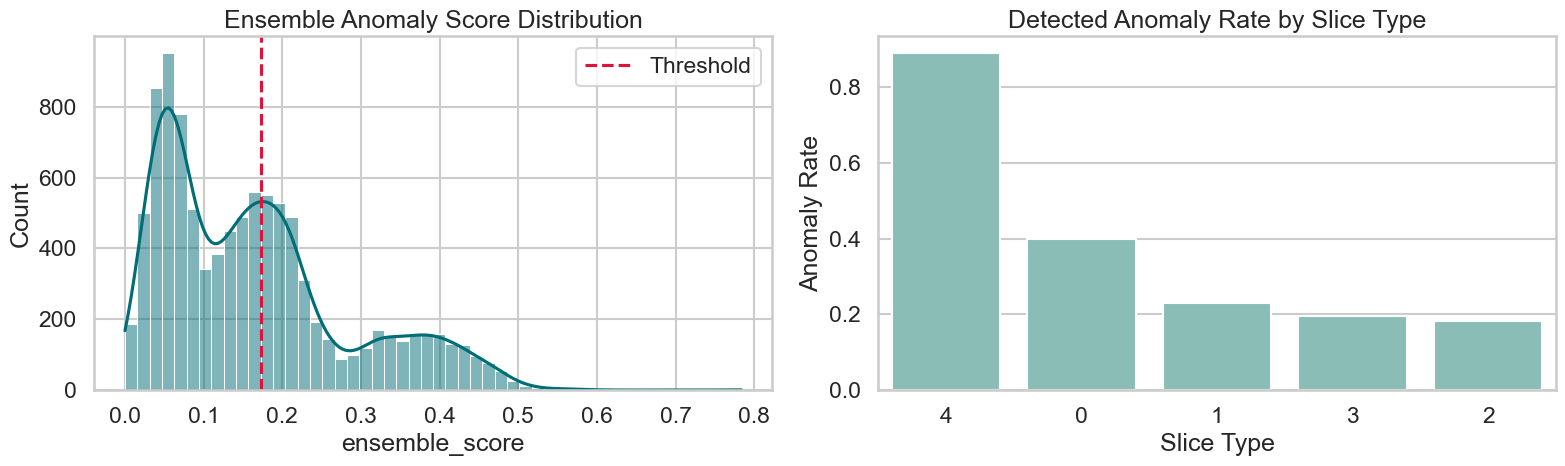

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['ensemble_score'], bins=50, kde=True, ax=axes[0], color='#006d77')
axes[0].axvline(threshold, color='crimson', linestyle='--', label='Threshold')
axes[0].set_title('Ensemble Anomaly Score Distribution')
axes[0].legend()

risk_by_slice = df.groupby('Slice_Type')['ensemble_anomaly'].mean().sort_values(ascending=False)
sns.barplot(x=risk_by_slice.index.astype(str), y=risk_by_slice.values, ax=axes[1], color='#83c5be')
axes[1].set_title('Detected Anomaly Rate by Slice Type')
axes[1].set_xlabel('Slice Type')
axes[1].set_ylabel('Anomaly Rate')

plt.tight_layout()
plt.show()

In [30]:
top_anomalies = (
    df.sort_values('ensemble_score', ascending=False)
      .head(200)
      .copy()
)

export_cols = [
    'Slice_Type', 'SLA_Respected', 'QoS_Probability', 'Aggregated_QoS_Score',
    'premium_intent_score', 'premium_intent_flow', 'is_best_effort_slice',
    'iso_score', 'ae_score', 'ensemble_score', 'ensemble_anomaly', 'proxy_anomaly_label'
]
export_cols = [c for c in export_cols if c in top_anomalies.columns]

top_anomalies[export_cols].to_csv('../data/top_detected_anomalies_best_effort.csv', index=False)
print('Export done: ../data/top_detected_anomalies_best_effort.csv')
display(top_anomalies[export_cols].head(20))

Export done: ../data/top_detected_anomalies_best_effort.csv


,Slice_Type,SLA_Respected,QoS_Probability,Aggregated_QoS_Score,premium_intent_score,premium_intent_flow,is_best_effort_slice,iso_score,ae_score,ensemble_score,ensemble_anomaly,proxy_anomaly_label
1257,0,0,0.604812,0.298181,203.75000,1,0,0.606422,1.000000,0.783532,1,0
322,0,0,0.203949,0.244730,203.75000,1,0,0.843406,0.682541,0.771017,1,0
3388,0,0,0.248973,0.298759,203.75000,1,0,0.854020,0.502420,0.695800,1,0
6289,0,0,0.249913,0.299886,203.75000,1,0,0.971612,0.154435,0.603882,1,0
256,0,0,0.089824,0.107780,203.75000,1,0,1.000000,0.067552,0.580398,1,0
2376,0,0,0.249986,0.299974,203.75000,1,0,0.984535,0.059567,0.568299,1,0
6535,0,0,0.249919,0.299894,203.75000,1,0,0.989154,0.048239,0.565742,1,0
570,0,0,0.205319,0.246374,203.75000,1,0,0.950405,0.087229,0.561976,1,0
3948,0,0,0.249323,0.299179,203.75000,1,0,0.907225,0.135711,0.560044,1,0
7702,0,0,0.248984,0.298772,203.75000,1,0,0.886793,0.143041,0.552105,1,0


## Interpretation and Action Plan
- The model stack detects both isolated hard outliers and multivariate soft anomalies.
- Priority incidents are records with high ensemble score and premium-intent in best-effort slices.
- MLOps next step: schedule periodic scoring and trigger alerts when anomaly rate or premium misrouting share exceeds control limits.

This notebook is ready for phase-2 validation with reproducible metrics and business-oriented outputs.

## Executive Summary (Phase 2 Validation)

1. Objective
Detect premium-intent traffic that behaves abnormally in best-effort slices to reduce SLA violations and protect high-value service revenue.

2. Method
A dual unsupervised detector was built: Isolation Forest for hard outliers and reconstruction-based MLP for multivariate drift; both are fused into an ensemble score.

3. Key Metrics
Threshold calibration is learned on a calibration subset, then validated on a hold-out evaluation subset using precision, recall, F1, ROC-AUC, and PR-AUC.

4. SLA Impact
Detected incidents are prioritized when premium-intent flows are found in best-effort slices, enabling targeted remediation before customer-impact escalation.

5. MLOps Plan
Operationalize with scheduled scoring, drift monitoring, threshold review cadence, and alerting based on anomaly rate and premium misrouting share.

## Commentaires Basés Sur Les Outputs (Lecture Guidée)

### Cellule 3 - Chargement des données
- Le dataset contient 10000 lignes et 27 variables. C'est un volume suffisant pour une première modélisation non supervisée robuste.
- Les données couvrent les dimensions clés QoS/SLA: latence, jitter, perte, débit, gaps et scores agrégés.

### Cellule 6 - Feature engineering métier
- Le type de slice identifié comme best-effort est le type 4.
- Le taux d'anomalies proxy est de 0.1623 (16.23%), ce qui confirme un déséquilibre réaliste entre comportements normaux et cas à risque.
- La définition proxy est cohérente avec le besoin métier: premium-intent + best-effort + QoS faible ou SLA non respecté.

### Cellule 8 - Split scientifique
- 25 features sont utilisées pour la détection.
- Split méthodologique correct: 7000 lignes calibration, 3000 lignes évaluation hold-out.
- Sous-ensemble de référence majoritairement normal pour l'entraînement: 5864 lignes.
- Ce protocole réduit le biais de validation et améliore la crédibilité scientifique.

### Cellule 11 - Calibration du seuil
- Seuil baseline (98e percentile sur calibration): 0.4536.
- Seuil calibré (optimisé F1 sur calibration): 0.1726.
- Taux d'anomalies global prédit: 0.3989.
- Interprétation: le seuil optimisé privilégie la détection des incidents (rappel élevé), ce qui est adapté au risque SLA.

### Cellule 12 - Performance sur hold-out (évaluation réelle)
- Precision: 0.3738.
- Recall: 0.8973.
- F1-score: 0.5278.
- ROC-AUC: 0.8076.
- PR-AUC: 0.3066.
- Lecture métier: le modèle capture la majorité des incidents à risque (rappel élevé), au prix d'alertes supplémentaires à filtrer en exploitation.

### Cellule 12 - Sensibilité au seuil (robustesse décisionnelle)
- Low threshold (0.1467): precision 0.3356, recall 1.0000, F1 0.5026, anomaly rate 0.4837.
- Balanced threshold (0.1726): precision 0.3738, recall 0.8973, F1 0.5278, anomaly rate 0.3897.
- High threshold (0.2072): precision 0.3444, recall 0.5770, F1 0.4313, anomaly rate 0.2720.
- Conclusion pratique: la politique Balanced est le meilleur compromis global pour la phase actuelle.

### KPI métier final
- Part des anomalies détectées qui sont premium-intent dans best-effort (subset évaluation): 0.4962.
- Cela signifie qu'environ 1 alerte sur 2 cible exactement le problème business critique de mauvais aiguillage premium.

### Message soutenance conseillé
- Le pipeline est scientifiquement valide (split calibration/hold-out), opérationnellement interprétable (analyse de sensibilité), et orienté valeur métier (focus SLA et revenus premium).